<a href="https://colab.research.google.com/github/sahdahx/Komstat-II/blob/main/KomstatII_W5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Komputasi Statistika II | 17th Mar 2026

## Regresi Logistik

- Regresi logistik adalah metode statistik yang digunakan untuk memodelkan hubungan antara variabel independen (X) dan probabilitas suatu kejadian (Y = 1 atau Y = 0).
- Regresi logistik menggunakan fungsi logistik (sigmoid) untuk memastikan bahwa probabilitas tetap dalam kisaran yang valid.

Secara matematis, model regresi logistik didefinisikan sebagai berikut:

$$
p(X) = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}}
$$

  - $p(X)$ adalah probabilitas kejadian $(Y = 1)$ berdasarkan nilai $X$.
  - $\beta_0$ adalah intercept (konstanta model).
  - $\beta_1$ adalah koefisien regresi yang menunjukkan dampak perubahan $X$ terhadap probabilitas kejadian $(Y = 1)$.

---

## Odds dan Log Odds (Logit)

Regresi logistik juga sering dianalisis menggunakan konsep *odds*:

$$
\text{Odds} = \frac{p(X)}{1 - p(X)} = e^{\beta_0 + \beta_1 X}
$$

Persamaan logit:

$$
\log \left( \frac{p(X)}{1 - p(X)} \right) = \beta_0 + \beta_1 X
$$

Keterangan:
- Probability berada pada rentang $[0, 1]$
- Odds berada pada rentang $[0, +\infty)$
- Log of Odds berada pada rentang $(-\infty, +\infty)$

Interpretasi koefisien:
- Nilai $\beta_1$ menunjukkan perubahan dalam log odds ketika $X$ meningkat satu satuan.
- Jika $\beta_1$ positif, maka peningkatan $X$ meningkatkan probabilitas $(Y = 1)$.
- Jika $\beta_1$ negatif, maka peningkatan $X$ menurunkan probabilitas $(Y = 1)$.

---

## Simple Logistic Regression

- Regresi logistik sederhana (*Simple Logistic Regression*) adalah metode statistik yang digunakan untuk memodelkan hubungan antara satu variabel independen (prediktor) dan satu variabel dependen (respon) yang bersifat biner (misalnya, 0 dan 1 atau "Ya" dan "Tidak").

- Model regresi logistik sederhana secara matematis dinyatakan sebagai:

$$
P(Y = 1 \mid X) = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}}
$$

- atau dalam bentuk logit:

$$
\log \left( \frac{P(Y = 1)}{1 - P(Y = 1)} \right) = \beta_0 + \beta_1 X
$$

- dengan $P(Y = 1 \mid X)$ adalah probabilitas kejadian suatu peristiwa (misalnya, "sukses" atau "positif").

---

## Uji Hipotesis

### 1. Uji Overall (Likelihood Ratio Test - LLR Test)

Hipotesis yang diuji:

- $H_0: \beta_1 = \beta_2 = \dots = \beta_n = 0$  
  (model tidak lebih baik dari model tanpa prediktor)

- $H_1:$ Setidaknya ada satu $\beta_i \neq 0$  
  (model lebih baik daripada tanpa prediktor)

### 2. Uji Parsial untuk Konstanta (Intercept)

Hipotesis yang diuji:

- $H_0: \beta_0 = 0$  
  (intercept tidak berbeda secara signifikan dari nol)

- $H_1: \beta_0 \neq 0$  
  (intercept berbeda secara signifikan dari nol)

### 3. Uji Parsial untuk Koefisien

Hipotesis yang diuji:

- $H_0: \beta_i = 0$  
  (koefisien tidak berpengaruh secara signifikan)

- $H_1: \beta_i \neq 0$  
  (koefisien berpengaruh secara signifikan terhadap log-odds)

### 4. Evaluasi Goodness-of-Fit

- Deviance / df residual

$$
\frac{\text{Deviance}}{\text{df residual}} \approx 1
$$

Jika nilai mendekati 1, maka model cukup fit.

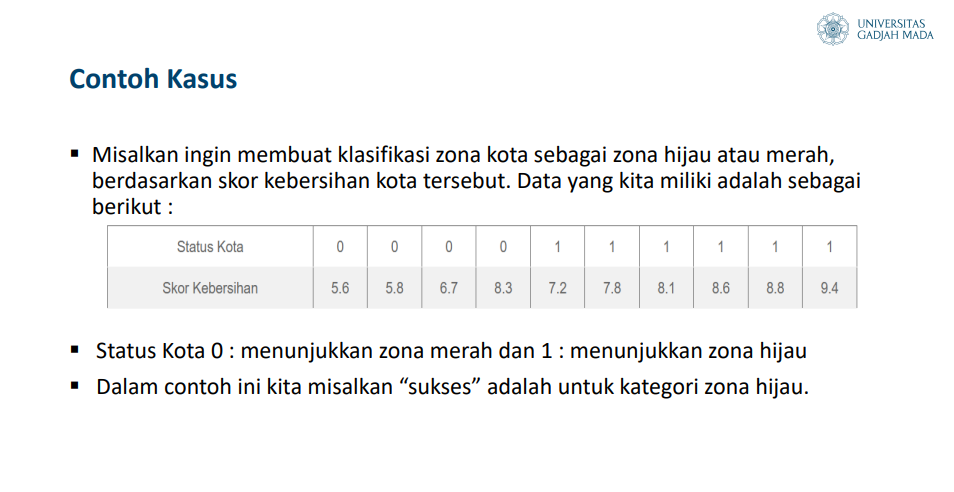

In [ ]:
import os
from IPython.display import display, Image
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

display(Image('slide09.png'))

In [ ]:
# Loading training dataset
status = [0,0,0,0,1,1,1,1,1,1]

# Pada statmodels jika menginginkan beta-0 (intercept), perlu membuat list [1, 1, ..., 1]
intercept = [1]*10
skor = [5.6,5.8,6.7,8.3,7.2,7.8,8.1,8.5,8.8,9.4]
penjelas = pd.DataFrame({'intercept':intercept, 'skor':skor})

# Membuat model dengan variabel respon: status
# Variabel penjelas adalah: intercept + skor

# Model logistik
log_reg = sm.Logit(status, penjelas).fit()

# Output
print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.389357
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                   10
Model:                          Logit   Df Residuals:                        8
Method:                           MLE   Df Model:                            1
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.4215
Time:                        09:18:08   Log-Likelihood:                -3.8936
converged:                       True   LL-Null:                       -6.7301
Covariance Type:            nonrobust   LLR p-value:                   0.01723
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -12.9314      7.934     -1.630      0.103     -28.482       2.619
skor           1.7718      1.

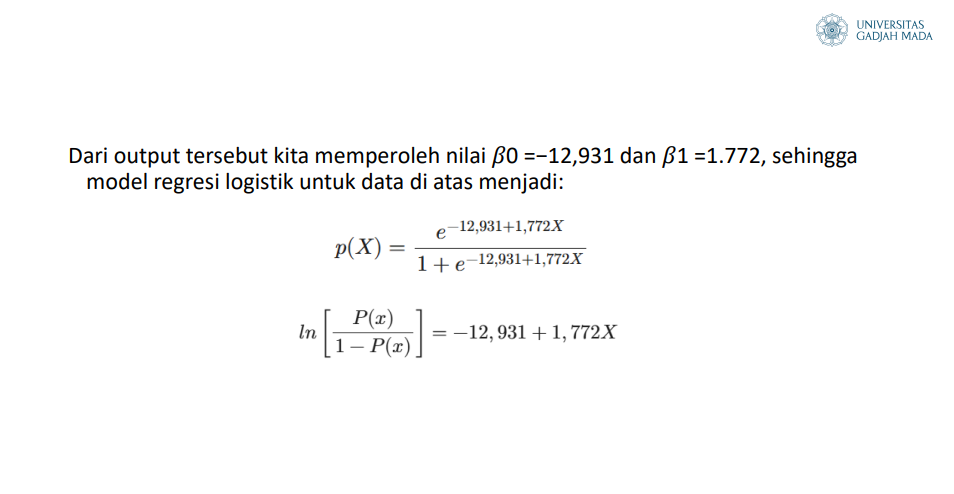

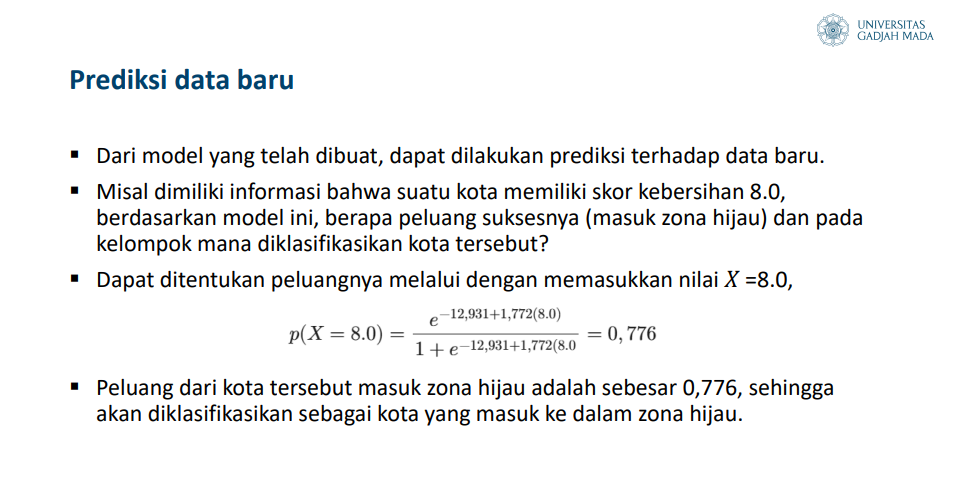

In [ ]:
display(Image('slide12.png'))
display(Image('slide13.png'))

In [ ]:
# Data baru jika skor kebersihan = 8.0
newdata = pd.DataFrame({'intercept':[1], 'skor':[8.0]})
p = log_reg.predict(newdata)
zona = 1 if p[0] > 0.5 else 0

print(f'peluang {p[0]}, zona {zona}')

peluang 0.7760577253436567, zona 1


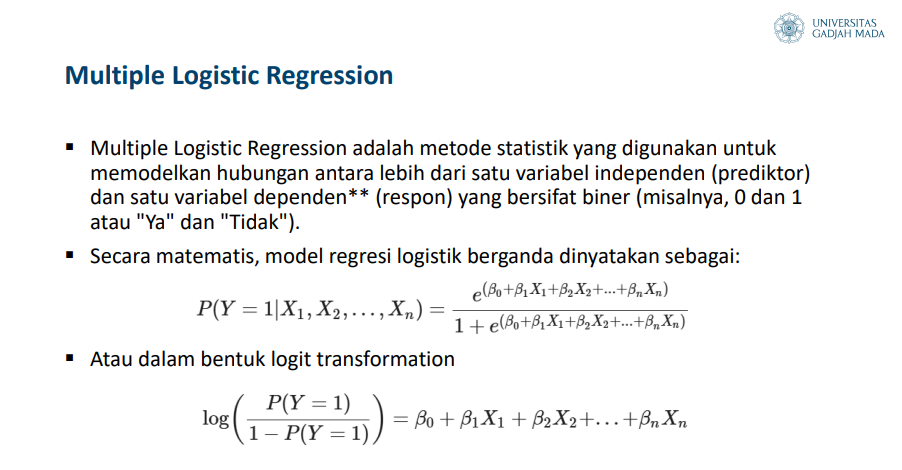

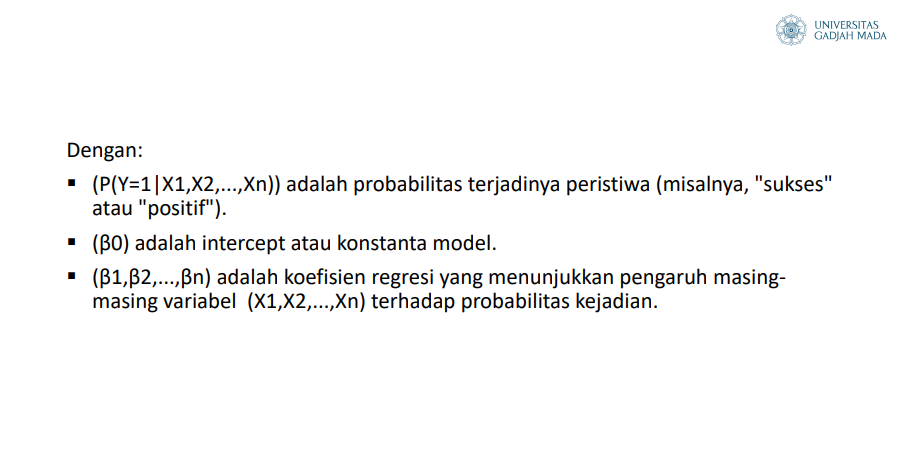

In [ ]:
display(Image('slide15.png'))
display(Image('slide16.png'))